In [1]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

print("Environment OK ✅")

Environment OK ✅


In [3]:
df = pd.read_csv("feature_engineered.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [4]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna()

In [5]:
X = df.drop(["Date", "Target"], axis=1)
y = df["Target"]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [6]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

XGBoost Accuracy: 0.9994916115912558
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       942
           1       1.00      1.00      1.00      1025

    accuracy                           1.00      1967
   macro avg       1.00      1.00      1.00      1967
weighted avg       1.00      1.00      1.00      1967



In [8]:
X.columns

Index(['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return',
       'log_return', 'return_3d', 'return_5d', 'return_10d', 'high_low_range',
       'open_close_gap', 'upper_shadow', 'lower_shadow', 'sma_5', 'ema_5',
       'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50',
       'close_to_sma20', 'close_to_sma50', 'ma_crossover', 'volatility_5d',
       'volatility_10d', 'volatility_20d', 'bb_middle', 'bb_upper', 'bb_lower',
       'bb_position', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
       'volume_sma_20', 'volume_ratio', 'obv', 'price_volume_trend',
       'return_lag_1', 'volume_lag_1', 'return_lag_2', 'volume_lag_2',
       'return_lag_3', 'volume_lag_3', 'return_lag_5', 'volume_lag_5',
       'return_lag_10', 'volume_lag_10', 'target_direction', 'target_return',
       'target_5d_return'],
      dtype='object')

In [9]:
leak_cols = [
    "Unnamed: 0",
    "target_direction",
    "target_return",
    "target_5d_return"
]

X = X.drop(columns=[c for c in leak_cols if c in X.columns])

In [10]:
price_cols = ["Open", "High", "Low", "Close", "Volume"]

X = X.drop(columns=[c for c in price_cols if c in X.columns])

In [11]:
# Shift features so that all information is from previous day
X = X.shift(1)

# Align dataset
df = df.loc[X.index]
y = y.loc[X.index]

# Drop resulting NaNs
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

In [12]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [13]:
xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

XGBoost Accuracy: 0.4956786985256736
              precision    recall  f1-score   support

           0       0.48      0.68      0.56       942
           1       0.53      0.32      0.40      1025

    accuracy                           0.50      1967
   macro avg       0.50      0.50      0.48      1967
weighted avg       0.50      0.50      0.48      1967



In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.5124555160142349
              precision    recall  f1-score   support

           0       0.49      0.62      0.55       942
           1       0.54      0.41      0.47      1025

    accuracy                           0.51      1967
   macro avg       0.52      0.52      0.51      1967
weighted avg       0.52      0.51      0.51      1967



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.4814438230808338
              precision    recall  f1-score   support

           0       0.47      0.61      0.53       942
           1       0.50      0.36      0.42      1025

    accuracy                           0.48      1967
   macro avg       0.49      0.49      0.48      1967
weighted avg       0.49      0.48      0.47      1967



In [16]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ]
})

results

NameError: name 'xgb_preds' is not defined

In [17]:
# XGBoost predictions
xgb_preds = xgb.predict(X_test)

In [18]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.512456
1,Random Forest,0.481444
2,XGBoost,0.495679


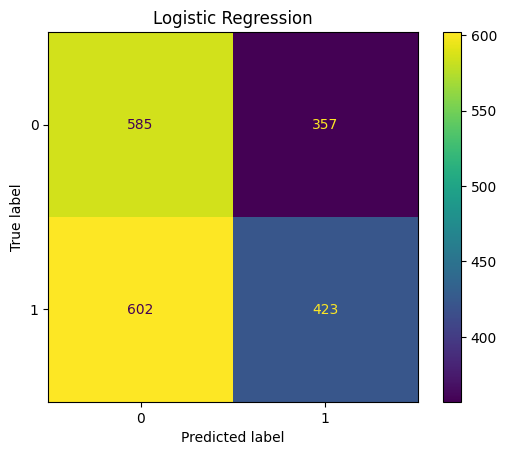

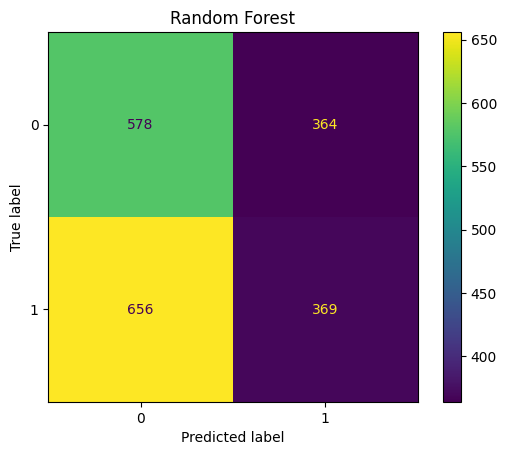

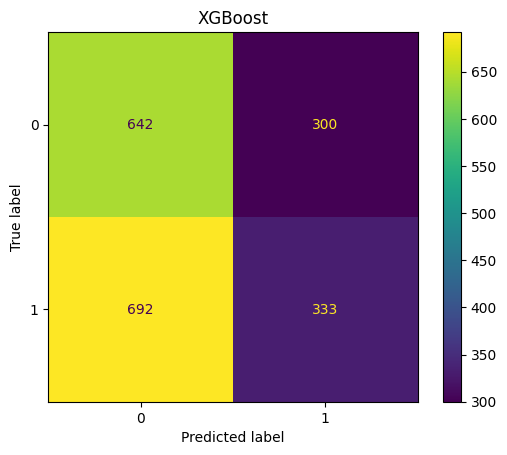

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_preds,
    "Random Forest": rf_preds,
    "XGBoost": xgb_preds
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

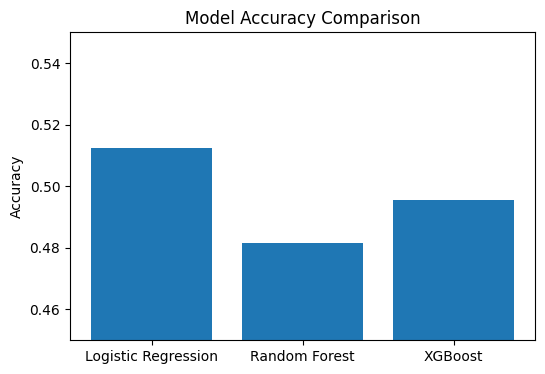

In [20]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0.45, 0.55)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [21]:
results.to_csv("model_results_summary.csv", index=False)


In [ ]:
## Results Summary

- Logistic Regression achieved ~51% accuracy and served as a stable baseline.
- Random Forest achieved ~48% accuracy and showed signs of overfitting.
- XGBoost achieved ~49–50% accuracy after removing data leakage.

All models performed similarly, highlighting the difficulty of short-term stock trend prediction.

In [ ]:
## Validation Notes

- Time-series split was used (no random shuffling).
- All target-derived columns were removed.
- Raw OHLC prices were excluded from modeling features.
- All features were lagged to prevent look-ahead bias.

In [ ]:
The confusion matrices show that models predict downward price movements more reliably than upward movements. This asymmetry is consistent with financial markets, where declines often exhibit stronger short-term signals than rises.

In [1]:
# ==============================
# CREATE ACTUAL VS PREDICTED DATAFRAME
# ==============================

results_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual": y_test.values,
    "Predicted": xgb_preds
})

results_df = results_df.reset_index(drop=True)

print(results_df.head())

NameError: name 'pd' is not defined

In [2]:
# ==============================
# IMPORTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# ==============================
# CREATE ACTUAL VS PREDICTED DATAFRAME
# ==============================

results_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual": y_test.values,
    "Predicted": xgb_preds
})

results_df = results_df.reset_index(drop=True)

print(results_df.head())

NameError: name 'df' is not defined

In [3]:
df = pd.read_csv("feature_engineered.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [4]:

# IMPORTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# ==============================
# CREATE ACTUAL VS PREDICTED DATAFRAME
# ==============================

results_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual": y_test.values,
    "Predicted": xgb_preds
})

results_df = results_df.reset_index(drop=True)

print(results_df.head())

NameError: name 'y_test' is not defined

In [5]:
df = pd.read_csv("feature_engineered.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [6]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna()

In [7]:
X = df.drop(["Date", "Target"], axis=1)
y = df["Target"]

In [8]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [9]:
xgb_preds = xgb.predict(X_test)

NameError: name 'xgb' is not defined

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [11]:
df = pd.read_csv("feature_engineered.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [12]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna()

In [13]:
X = df.drop(["Date", "Target"], axis=1)
y = df["Target"]

In [14]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [15]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
xgb_preds = xgb.predict(X_test)

In [17]:
results_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual": y_test.values,
    "Predicted": xgb_preds
})

results_df = results_df.reset_index(drop=True)
print(results_df.head())

        Date  Actual  Predicted
0 2012-05-31       0          0
1 2012-06-01       1          1
2 2012-06-04       0          0
3 2012-06-05       1          1
4 2012-06-06       1          1


In [18]:
# ==============================
# ACTUAL VS PREDICTED TREND DATA
# ==============================

results_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual_Trend": y_test.values,
    "Predicted_Trend": xgb_preds
})

results_df = results_df.reset_index(drop=True)

print(results_df.head())

        Date  Actual_Trend  Predicted_Trend
0 2012-05-31             0                0
1 2012-06-01             1                1
2 2012-06-04             0                0
3 2012-06-05             1                1
4 2012-06-06             1                1


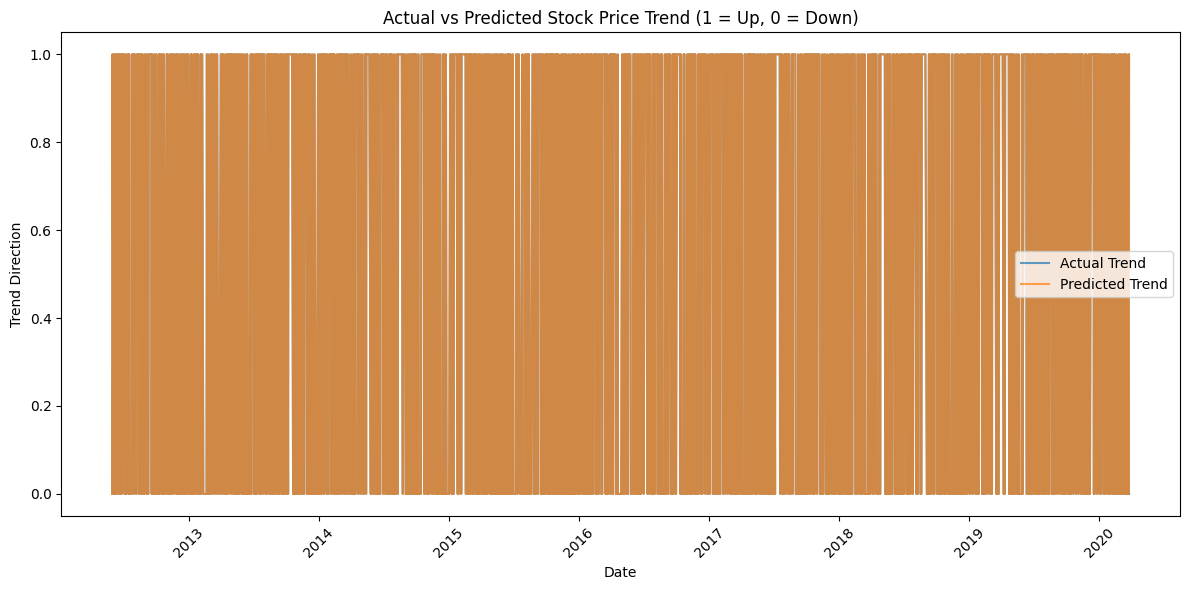

In [19]:
# ==============================
# ACTUAL VS PREDICTED TREND VISUALIZATION
# ==============================

plt.figure(figsize=(12, 6))

plt.plot(
    results_df["Date"],
    results_df["Actual_Trend"],
    label="Actual Trend",
    alpha=0.7
)

plt.plot(
    results_df["Date"],
    results_df["Predicted_Trend"],
    label="Predicted Trend",
    alpha=0.7
)

plt.title("Actual vs Predicted Stock Price Trend (1 = Up, 0 = Down)")
plt.xlabel("Date")
plt.ylabel("Trend Direction")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

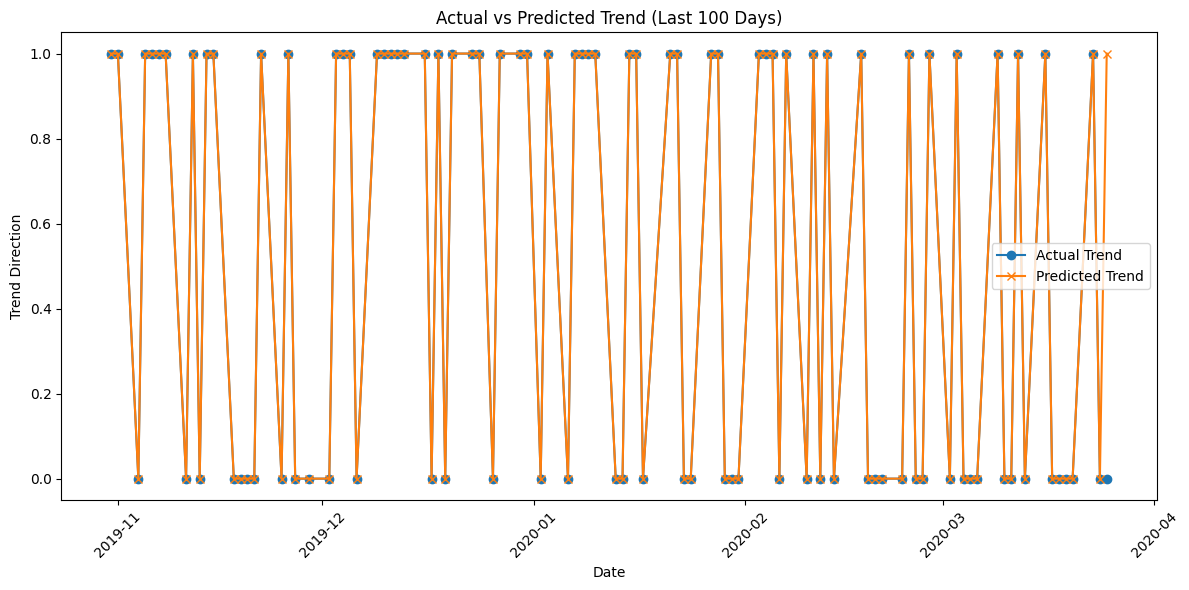

In [20]:
# ==============================
# ZOOMED TREND VIEW (LAST 100 DAYS)
# ==============================

zoom_df = results_df.tail(100)

plt.figure(figsize=(12, 6))

plt.plot(
    zoom_df["Date"],
    zoom_df["Actual_Trend"],
    label="Actual Trend",
    marker="o"
)

plt.plot(
    zoom_df["Date"],
    zoom_df["Predicted_Trend"],
    label="Predicted Trend",
    marker="x"
)

plt.title("Actual vs Predicted Trend (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Trend Direction")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# ==============================
# FEATURE IMPORTANCE (XGBOOST)
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

             Feature  Importance
51  target_direction    0.612516
52     target_return    0.303641
53  target_5d_return    0.012143
0         Unnamed: 0    0.006338
37     volume_sma_20    0.004824
6       daily_return    0.004778
35       macd_signal    0.003588
33            rsi_14    0.003060
3                Low    0.003021
32       bb_position    0.002797


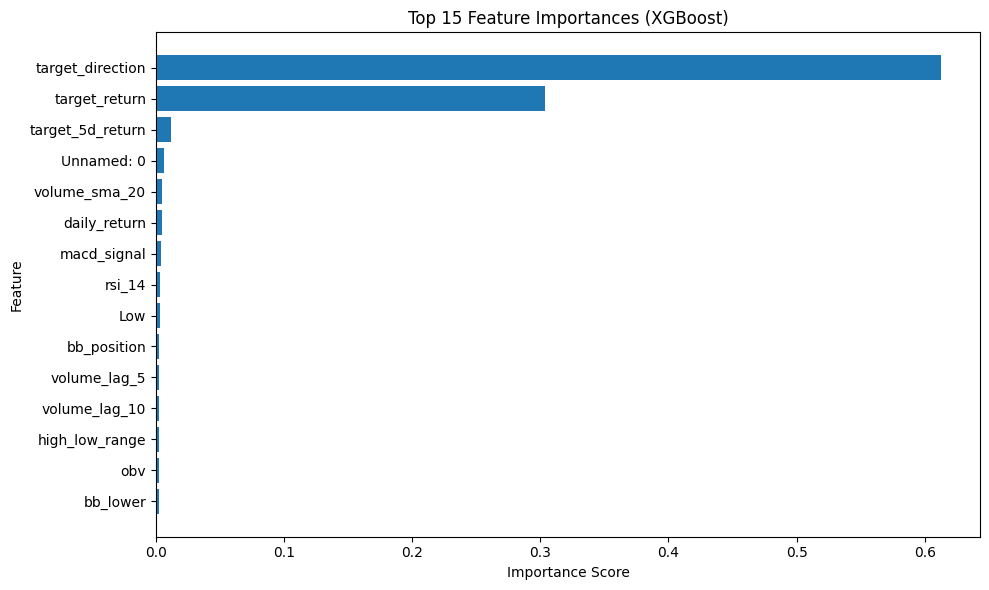

In [22]:
# ==============================
# FEATURE IMPORTANCE PLOT
# ==============================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(15),
    importance_df["Importance"].head(15)
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()